Starting simulation for N_CONSUMERS=10000000, NUM_ROUNDS=10

--- Running simulation for n_firms = 1 ---
Normal simulation took 73.11s.
No_Sharing simulation took 74.34s.
  Normal: CS=0.1250, PS=0.2500, TW=0.3750
  No_Sharing: CS=0.1250, PS=0.2500, TW=0.3750

--- Running simulation for n_firms = 2 ---
Normal simulation took 71.57s.
No_Sharing simulation took 68.88s.
  Normal: CS=0.2334, PS=0.1785, TW=0.4119
  No_Sharing: CS=0.2334, PS=0.1785, TW=0.4119

--- Running simulation for n_firms = 3 ---
Normal simulation took 52.84s.
No_Sharing simulation took 48.18s.
  Normal: CS=0.2743, PS=0.1374, TW=0.4117
  No_Sharing: CS=0.3369, PS=0.1213, TW=0.4583

--- Running simulation for n_firms = 4 ---
Normal simulation took 33.30s.
No_Sharing simulation took 46.45s.
  Normal: CS=0.1863, PS=0.1296, TW=0.3158
  No_Sharing: CS=0.4208, PS=0.0826, TW=0.5033

--- Running simulation for n_firms = 5 ---
Normal simulation took 27.80s.
No_Sharing simulation took 44.72s.
  Normal: CS=0.1139, PS=0.1165, TW=0.2

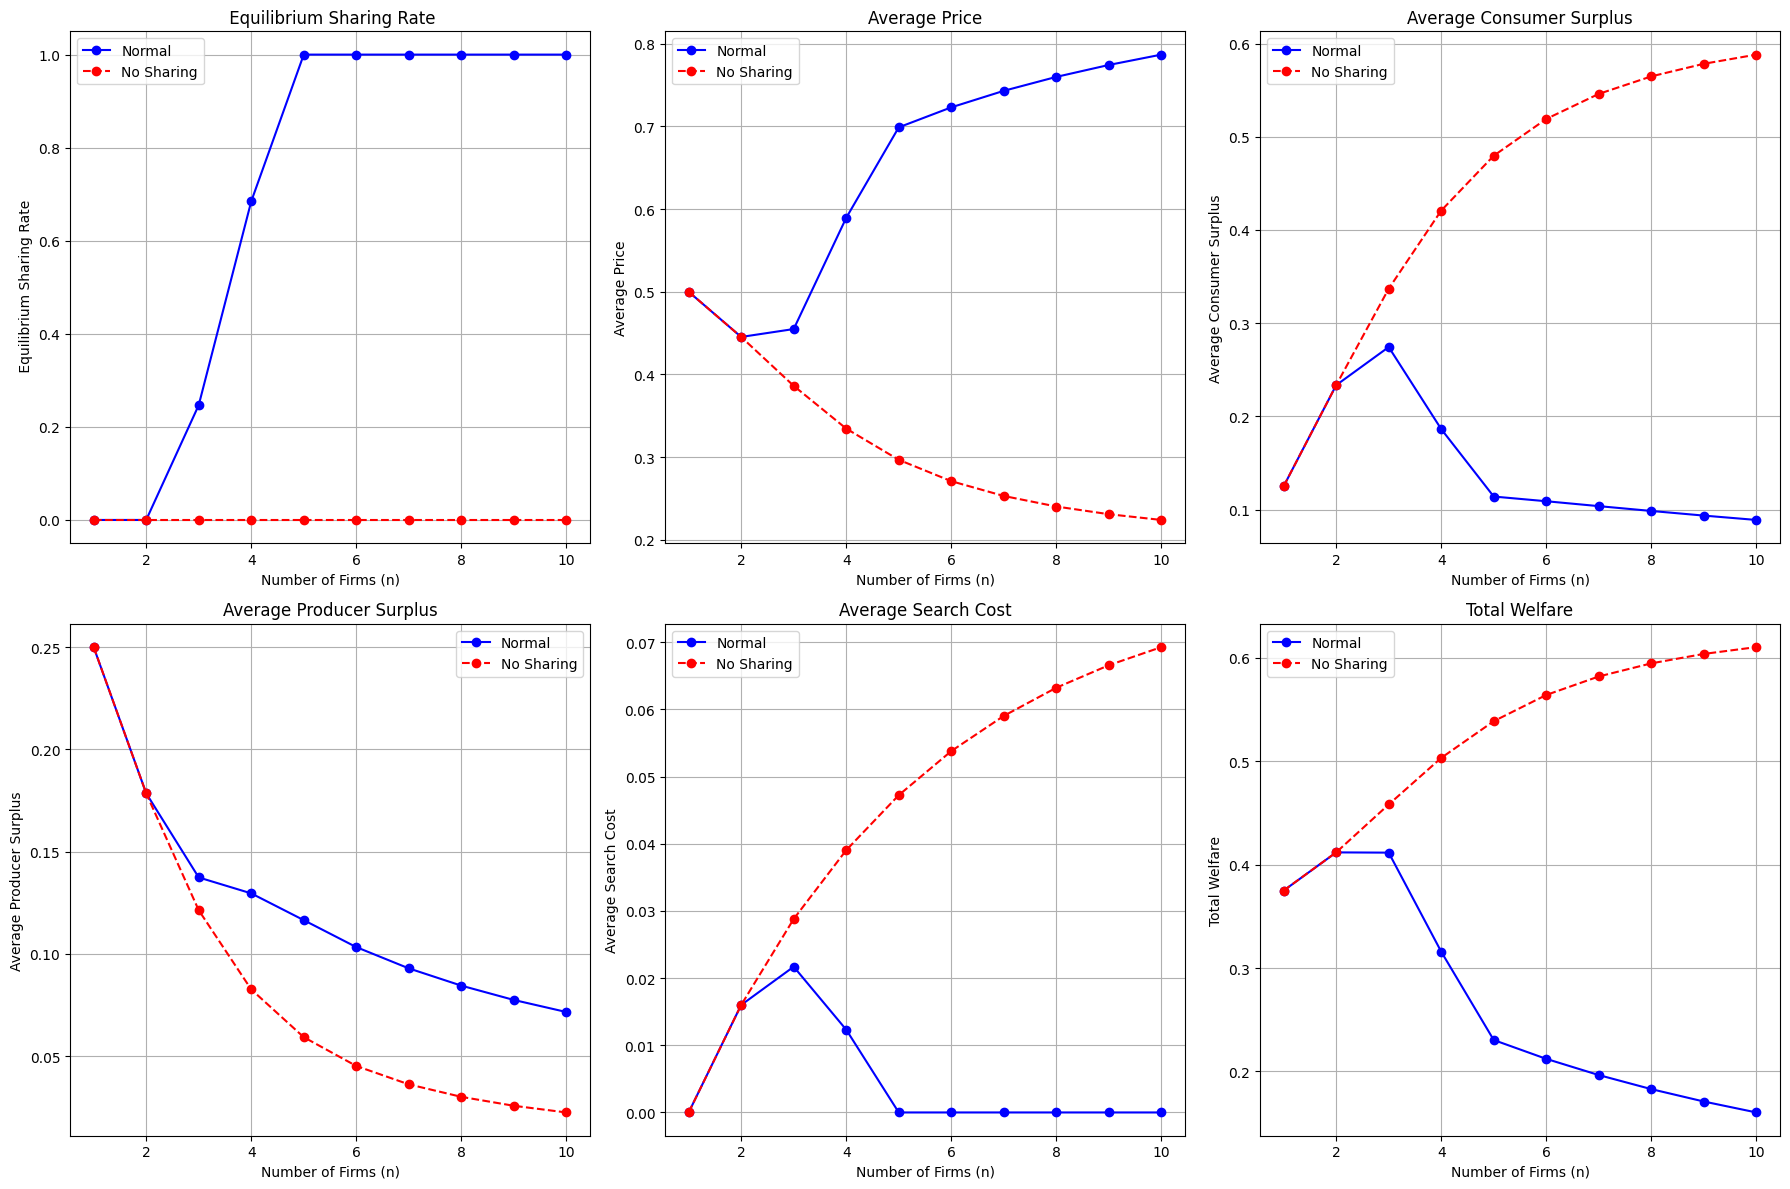

保存图: E:\DataMarket\Simulation\Picture\SW\SW_stack.png


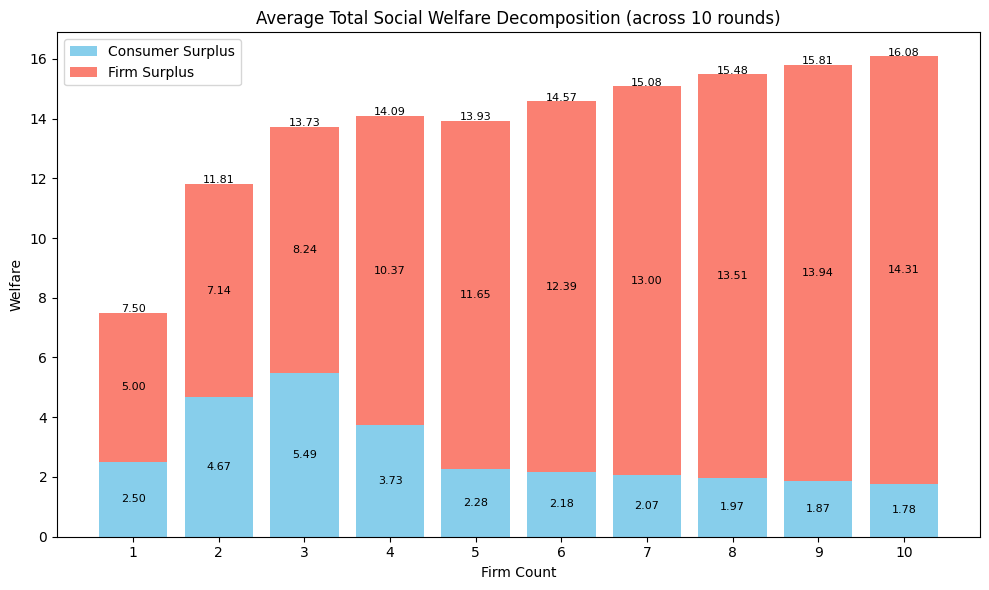

保存图: E:\DataMarket\Simulation\Picture\SW\FS.png


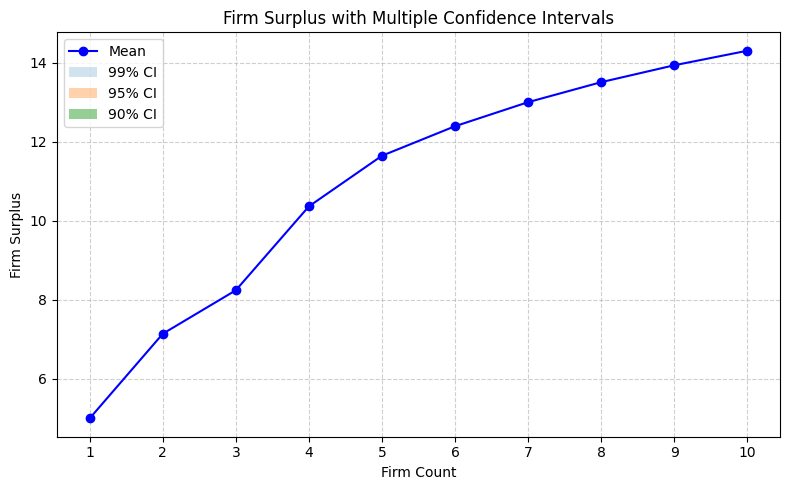

保存图: E:\DataMarket\Simulation\Picture\SW\CS.png


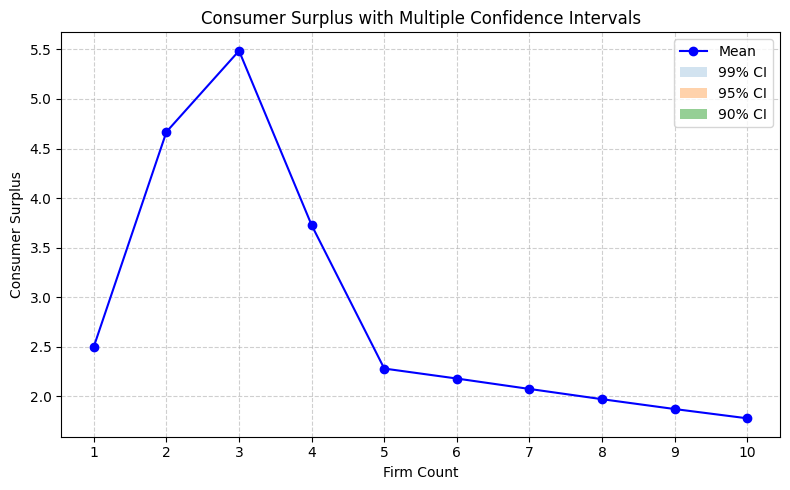

保存图: E:\DataMarket\Simulation\Picture\SW\SW.png


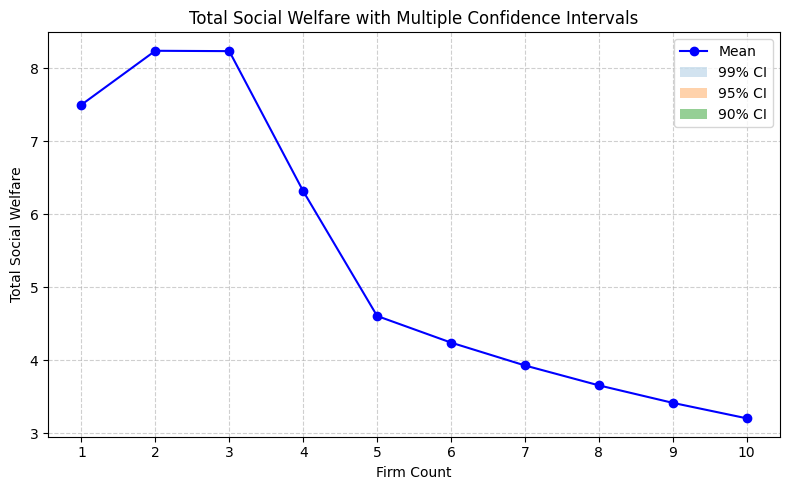

保存图: E:\DataMarket\Simulation\Picture\SW\CSR.png


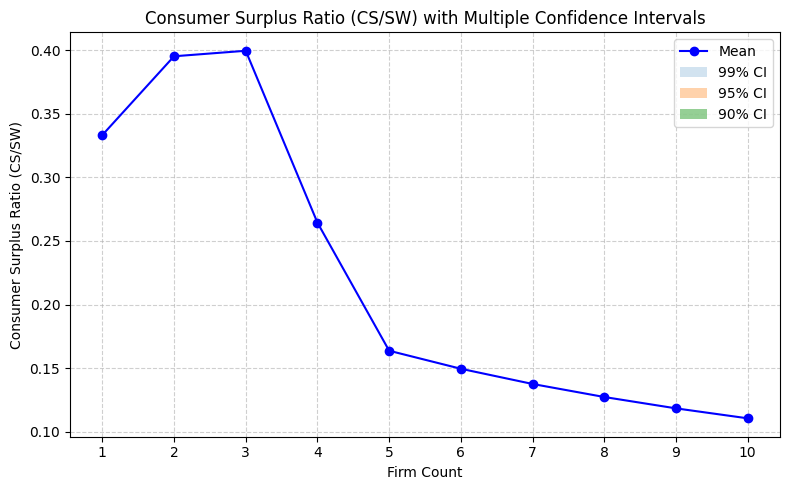

图已保存到: E:\DataMarket\Simulation\Picture\Gini\gini_trend.png


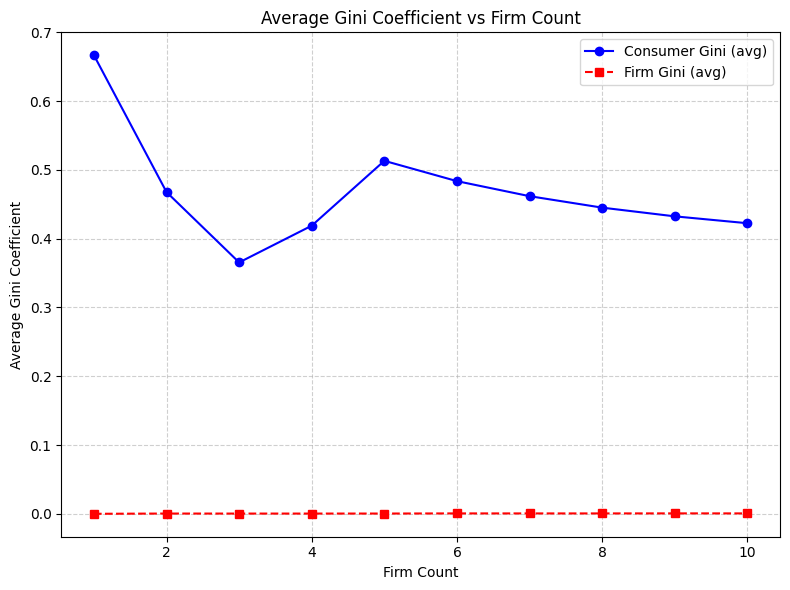

In [3]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import csv
import time  # For timing
import pandas as pd
from scipy import stats
import os
from joblib import Parallel, delayed

# --- Constants for consumer behavior (extracted from Consumer class for global access) ---
# These are fixed for a given simulation run based on params
_GLOBAL_V_DIST = None
_GLOBAL_R_VALUE = None
_GLOBAL_N_FIRMS = None
_GLOBAL_SEARCH_COST = None

# Pre-calculate Delta for sharing decision, as it only depends on global params
_GLOBAL_DELTA_SHARING = 0.0

def _calculate_globals_delta_sharing():
    """Calculates Delta for sharing decision once."""
    low, high = _GLOBAL_V_DIST['low'], _GLOBAL_V_DIST['high']
    n = _GLOBAL_N_FIRMS
    r = _GLOBAL_R_VALUE

    def integrand(v):
        F_v = (v - low) / (high - low)
        return F_v - F_v ** n

    # Ensure lower bound for quad is at least low, and within distribution range
    r_for_quad = max(r, low)
    if r_for_quad >= high:  # If retention value is at or above max valuation, Delta is 0
        return 0.0

    try:
        # Added limit for robustness in numerical integration
        delta, _ = quad(integrand, r_for_quad, high, limit=50)
    except Exception as e:
        print(f"Warning: quad integration failed for Delta calculation (r={r}, n={n}). Error: {e}. Returning 0.")
        delta = 0.0

    # Delta should not be negative in this context, ensure it's at least 0.
    return max(0.0, delta)

class Consumer:
    # Consumer objects will now be very light, mostly just holding their unique tau
    def __init__(self, idx, privacy_cost):
        self.idx = idx
        self.τ = privacy_cost
        self.share = False  # Decided later
        self.utility = 0.0
        self.purchase_from = None
        self.search_times = 0

class Firm:
    def __init__(self, idx, marginal_cost, v_dist, r_value):
        self.idx = idx
        self.c = marginal_cost
        self.v_dist = v_dist
        self.r = r_value
        self.price = None
        self.demand = 0.0
        self.profit = 0.0

    def optimize_price(self, σ, n, market_price, global_firm_condition_met=True):
        """
        贝叶斯纳什均衡定价
        :param σ: Data sharing rate
        :param n: Number of firms
        :param market_price: Current market price (for non-shared demand estimation)
        :param global_firm_condition_met: Whether the general condition (r-c > (1-F_r^n)/...) is met.
                                          Calculated once in SimulationPlatform.
        """
        r = self.r
        v_low = self.v_dist['low']
        v_high = self.v_dist['high']

        v_span = v_high - v_low
        if v_span == 0:  # Avoid division by zero
            self.price = self.c
            return

        # The 'condition' check is now pre-calculated in SimulationPlatform if it's identical for all firms
        if not global_firm_condition_met:
            # Fallback price: if the general condition for profitable pricing isn't met,
            # firms might price very aggressively or just at retention value/near max valuation.
            self.price = min(r, v_high * 0.999)
            return

        def d_profit_d_pi(p_i, p_avg):
            # Shared demand derivative
            F_pi = np.clip((p_i - v_low) / v_span, 0, 1)
            q_s = (1 - F_pi ** n) / n
            # Derivative of q_s with respect to p_i
            dq_s = -F_pi ** (n - 1) / v_span if F_pi < 1 else 0

            # Non-shared demand and its derivative
            q_ns = self._non_shared_demand(p_i, p_avg, r, n)
            dq_ns = self._deriv_non_shared(p_i, p_avg, r, n)

            Q = σ * q_s + (1 - σ) * q_ns
            dQ = σ * dq_s + (1 - σ) * dq_ns
            return Q + (p_i - self.c) * dQ

        lower_bound = self.c
        upper_bound = r  # A reasonable upper bound for price, as consumers won't pay more than r to search

        try:
            # Check the sign of foc at the boundaries to ensure brentq works
            foc_lower = d_profit_d_pi(lower_bound, market_price)
            foc_upper = d_profit_d_pi(upper_bound, market_price)

            # If signs are the same, brentq will fail.
            # This indicates no root or multiple roots, or root outside bracket.
            if foc_lower * foc_upper > 0:
                self.price = np.clip((self.c + r) / 2, lower_bound, upper_bound)  # Fallback to midpoint
            else:
                result = root_scalar(
                    lambda p_i: d_profit_d_pi(p_i, market_price),
                    method='brentq',
                    bracket=[lower_bound, upper_bound],
                    maxiter=100
                )
                self.price = result.root
        except Exception as e:
            # Fallback if root finding fails, e.g., no root in bracket or sign error
            self.price = np.clip((self.c + r) / 2, lower_bound, upper_bound)

    def _non_shared_demand(self, p_i, p, r, n):
        v_low = self.v_dist['low']
        v_high = self.v_dist['high']
        v_span = v_high - v_low
        if v_span == 0: return 0.0

        F_r = np.clip((r - v_low) / v_span, 0, 1)

        F_term = np.clip((r - p + p_i - v_low) / v_span, 0, 1)

        numerator = (1 - F_term) * (1 - F_r ** n)
        denominator = n * (1 - F_r)
        term1 = numerator / denominator if denominator > 1e-9 else 0.0

        lower_int = max(p_i, v_low)
        upper_int = min(r - p + p_i, v_high)

        if lower_int >= upper_int:
            term2 = 0.0
        else:
            def integrand(v_i):
                offset = v_i - p_i + p
                F_offset = np.clip((offset - v_low) / v_span, 0, 1)
                return F_offset ** (n - 1) / v_span

            term2, _ = quad(integrand, lower_int, upper_int, limit=50)

        return term1 + term2

    def _deriv_non_shared(self, p_i, p, r, n):
        v_low = self.v_dist['low']
        v_high = self.v_dist['high']
        v_span = v_high - v_low
        if v_span == 0: return 0.0

        F_r = np.clip((r - v_low) / v_span, 0, 1)
        f_density = 1 / v_span

        d_term1 = - f_density * (1 - F_r ** n) / (n * (1 - F_r)) if (1 - F_r) > 1e-9 else 0.0

        lower_bound_integral = max(p_i, v_low)
        upper_bound_integral = min(r - p + p_i, v_high)

        val_at_upper = r - p + p_i
        F_val_at_upper = np.clip((val_at_upper - v_low) / v_span, 0, 1)
        term_upper_boundary = F_val_at_upper ** (n - 1) * f_density if v_low <= val_at_upper <= v_high else 0.0

        val_at_lower = p_i
        F_val_at_lower = np.clip((val_at_lower - v_low) / v_span, 0, 1)
        term_lower_boundary = F_val_at_lower ** (n - 1) * f_density if v_low <= val_at_lower <= v_high else 0.0

        boundary_term = term_upper_boundary - term_lower_boundary

        if lower_bound_integral >= upper_bound_integral or n <= 1:
            integral_of_deriv = 0.0
        else:
            def integrand_of_deriv(v_i):
                offset = v_i - p_i + p
                F_offset = np.clip((offset - v_low) / v_span, 0, 1)
                return - (n - 1) * F_offset ** (n - 2) * (f_density ** 2)

            integral_of_deriv, _ = quad(integrand_of_deriv, lower_bound_integral, upper_bound_integral, limit=50)

        d_term2 = boundary_term + integral_of_deriv

        return d_term1 + d_term2

class SimulationPlatform:
    def __init__(self, n_firms, n_consumers, params):
        global _GLOBAL_V_DIST, _GLOBAL_R_VALUE, _GLOBAL_N_FIRMS, _GLOBAL_SEARCH_COST, _GLOBAL_DELTA_SHARING

        self.n = n_firms
        self.n_consumers = n_consumers
        self.params = params
        self.r = params['r']
        self.s = params['s']

        _GLOBAL_V_DIST = params['v_dist']
        _GLOBAL_R_VALUE = self.r
        _GLOBAL_N_FIRMS = self.n
        _GLOBAL_SEARCH_COST = self.s

        # Pre-calculate delta for sharing decision (only once per simulation run for tau-based decision)
        _GLOBAL_DELTA_SHARING = _calculate_globals_delta_sharing()

        self.firms = [Firm(i, params['c'], params['v_dist'], self.r) for i in range(n_firms)]

        self.consumer_taus = np.random.uniform(params['τ_low'], params['τ_high'], n_consumers)
        self.consumers = [Consumer(i, self.consumer_taus[i]) for i in range(n_consumers)]

        v_low, v_high = params['v_dist']['low'], params['v_dist']['high']
        self.all_consumer_valuations = np.random.uniform(v_low, v_high, (n_consumers, n_firms))

        # Robustness for global_firm_condition_met calculation
        if v_high - v_low == 0:
            self.global_firm_condition_met = False
        else:
            F_r = (self.r - v_low) / (v_high - v_low)
            F_r = np.clip(F_r, 0, 1)  # Ensure F_r is within [0, 1]
            f_r = 1 / (v_high - v_low)

            denominator_val = self.n * (F_r ** (self.n - 1)) * f_r

            if abs(denominator_val) < 1e-9:  # Check for near-zero denominator
                self.global_firm_condition_met = False
            else:
                self.global_firm_condition_met = (self.r - params['c']) > (1 - F_r ** self.n) / denominator_val

    def run_simulation(self, max_iter=50, tol=1e-7, fixed_sigma_value=None):
        """
        完整模拟流程
        :param fixed_sigma_value: If a float (0.0 to 1.0), force this sharing rate.
                                  If None, consumers decide based on tau.
        """
        start_time = time.time()

        # --- 1. Consumer Data Sharing Decision ---
        if fixed_sigma_value is not None:
            # Force sharing for a fixed_sigma_value proportion of consumers
            num_sharing_consumers = int(self.n_consumers * fixed_sigma_value)
            # Ensure num_sharing_consumers is within valid bounds [0, n_consumers]
            num_sharing_consumers = max(0, min(num_sharing_consumers, self.n_consumers))
            sharing_indices = np.random.choice(self.n_consumers, num_sharing_consumers, replace=False)
            self.consumer_shares = np.zeros(self.n_consumers, dtype=bool)
            self.consumer_shares[sharing_indices] = True
            σ = fixed_sigma_value
        else:
            # Consumers decide based on tau and pre-calculated Delta
            self.consumer_shares = (_GLOBAL_DELTA_SHARING >= self.consumer_taus)
            σ = np.mean(self.consumer_shares)

        # Update individual consumer objects (for consistent state, though mostly handled by numpy arrays)
        for i, c in enumerate(self.consumers):
            c.share = self.consumer_shares[i]

        pricing_start_time = time.time()

        # --- 2. Firm Price Optimization (Iterative Convergence) ---
        prices = np.full(self.n, self.r * 0.9)  # Initial prices
        market_price = 0.0  # Initialize market_price here to ensure it's always defined

        if self.n == 1:  # Single firm case
            self.firms[0].optimize_price(σ, self.n, prices[0], self.global_firm_condition_met)
            prices[0] = self.firms[0].price
            market_price = prices[0]  # Set market_price for n=1 case
        else:  # Multiple firms
            for iter_price in range(max_iter):
                current_iteration_market_price = np.mean(prices)
                new_prices = np.empty(self.n)
                for firm_idx, firm in enumerate(self.firms):
                    firm.optimize_price(σ, self.n, current_iteration_market_price, self.global_firm_condition_met)
                    new_prices[firm_idx] = firm.price

                price_diff = np.max(np.abs(new_prices - prices))
                prices = new_prices
                if price_diff < tol:
                    break
            market_price = np.mean(prices)  # Set market_price for n > 1 case after convergence

        # print(f"Firm pricing took {time.time() - pricing_start_time:.4f} seconds.")
        consumer_behavior_start_time = time.time()

        # --- 3. Consumer Search and Buy (Optimized for shared/non-shared) ---

        # Shared data consumers:
        shared_consumer_indices = np.where(self.consumer_shares)[0]
        if len(shared_consumer_indices) > 0:
            shared_consumer_valuations = self.all_consumer_valuations[shared_consumer_indices, :]
            net_utils_shared = shared_consumer_valuations - prices[np.newaxis, :]
            max_net_shared = np.max(net_utils_shared, axis=1)
            buys_shared_mask = max_net_shared > 0
            utility_shared = np.where(buys_shared_mask, max_net_shared - self.consumer_taus[shared_consumer_indices], -self.consumer_taus[shared_consumer_indices])

            for i, idx in enumerate(shared_consumer_indices):
                self.consumers[idx].utility = utility_shared[i]
                if buys_shared_mask[i]:
                    self.consumers[idx].purchase_from = np.argmax(net_utils_shared[i, :])
                else:
                    self.consumers[idx].purchase_from = None
                self.consumers[idx].search_times = 0  # No search for shared data consumers

        # Non-shared data consumers:
        non_shared_consumer_indices = np.where(~self.consumer_shares)[0]
        if len(non_shared_consumer_indices) > 0:
            non_shared_consumer_valuations = self.all_consumer_valuations[non_shared_consumer_indices, :]
            all_net_utilities = non_shared_consumer_valuations - prices[np.newaxis, :]

            purchase_firm_idx = np.full(len(non_shared_consumer_indices), -1, dtype=int)
            consumer_utilities = np.zeros(len(non_shared_consumer_indices))
            consumer_search_times = np.ones(len(non_shared_consumer_indices), dtype=int)

            search_orders = np.argsort(np.random.rand(len(non_shared_consumer_indices), self.n), axis=1)
            threshold = self.r - market_price
            purchased_mask = np.zeros(len(non_shared_consumer_indices), dtype=bool)

            for search_step in range(self.n):
                if np.all(purchased_mask):
                    break

                active_consumer_indices_in_batch = np.where(~purchased_mask)[0]
                current_firms_to_check = search_orders[active_consumer_indices_in_batch, search_step]
                current_net_utilities = all_net_utilities[active_consumer_indices_in_batch, current_firms_to_check]

                acceptable_mask = current_net_utilities >= threshold
                newly_purchased_indices_in_batch = active_consumer_indices_in_batch[acceptable_mask]

                if len(newly_purchased_indices_in_batch) > 0:
                    purchase_firm_idx[newly_purchased_indices_in_batch] = current_firms_to_check[acceptable_mask]
                    consumer_utilities[newly_purchased_indices_in_batch] = current_net_utilities[acceptable_mask]
                    consumer_search_times[newly_purchased_indices_in_batch] = search_step + 1
                    purchased_mask[newly_purchased_indices_in_batch] = True

            unpurchased_final_mask = (purchase_firm_idx == -1) & (~purchased_mask)
            if np.any(unpurchased_final_mask):
                unpurchased_indices_in_batch = np.where(unpurchased_final_mask)[0]
                for consumer_batch_idx in unpurchased_indices_in_batch:
                    # Consumer has searched all N firms
                    searched_firms_for_consumer = search_orders[consumer_batch_idx, :self.n]
                    net_u_for_searched = all_net_utilities[consumer_batch_idx, searched_firms_for_consumer]

                    if len(net_u_for_searched) > 0:
                        max_net_u = np.max(net_u_for_searched)
                        if max_net_u > 0:
                            best_firm_idx_in_search_path = searched_firms_for_consumer[np.argmax(net_u_for_searched)]
                            purchase_firm_idx[consumer_batch_idx] = best_firm_idx_in_search_path
                            consumer_utilities[consumer_batch_idx] = max_net_u
                        else:
                            consumer_utilities[consumer_batch_idx] = 0.0
                    else:
                        consumer_utilities[consumer_batch_idx] = 0.0
                    consumer_search_times[consumer_batch_idx] = self.n  # Always N searches if no purchase before

            # Subtract individual search costs for non-shared consumers
            search_costs_individual = (consumer_search_times - 1) * self.s
            consumer_utilities -= search_costs_individual

            for i, global_idx in enumerate(non_shared_consumer_indices):
                self.consumers[global_idx].utility = consumer_utilities[i]
                self.consumers[global_idx].purchase_from = int(purchase_firm_idx[i]) if purchase_firm_idx[i] != -1 else None
                self.consumers[global_idx].search_times = consumer_search_times[i]

        # print(f"Consumer search and buy took {time.time() - consumer_behavior_start_time:.4f} seconds.")

        # --- 4. Calculate Demand and Profit ---
        firm_purchase_counts = np.zeros(self.n, dtype=int)
        all_purchase_from_indices = np.array([c.purchase_from if c.purchase_from is not None else -1 for c in self.consumers])

        valid_purchases = all_purchase_from_indices[all_purchase_from_indices != -1]
        if len(valid_purchases) > 0:
            counts = np.bincount(valid_purchases, minlength=self.n)
            firm_purchase_counts = counts[:self.n]

        for firm_idx, firm in enumerate(self.firms):
            firm.demand = firm_purchase_counts[firm_idx] / self.n_consumers
            firm.profit = (firm.price - firm.c) * firm.demand

        # --- 5. Calculate Aggregated Metrics ---
        total_consumer_surplus = sum(c.utility for c in self.consumers)
        total_producer_surplus = sum(f.profit for f in self.firms)
        avg_consumer_surplus = total_consumer_surplus / self.n_consumers
        avg_producer_surplus = total_producer_surplus / self.n

        total_search_cost = sum((c.search_times - 1) * self.s for c in self.consumers if not c.share)
        avg_search_cost = total_search_cost / self.n_consumers

        # 社会总福利 = 平均消费者福利 + 平均企业利润（两者都是 per-consumer 量）
        total_welfare = avg_consumer_surplus + avg_producer_surplus

        # Calculate Gini coefficients
        consumer_utilities_array = np.array([c.utility for c in self.consumers])
        firm_profits_array = np.array([f.profit for f in self.firms])
        consumer_gini = gini_formula(consumer_utilities_array)
        firm_gini = gini_formula(firm_profits_array)

        # Calculate consumer surplus ratio based on totals
        total_surplus = total_consumer_surplus + total_producer_surplus * self.n_consumers  # Correct total producer surplus
        total_consumer_surplus_correct = total_consumer_surplus
        total_producer_surplus_correct = total_producer_surplus * self.n_consumers
        consumer_surplus_ratio = total_consumer_surplus_correct / total_surplus if total_surplus != 0 else 0.0

        # print(f"Aggregation took {time.time() - consumer_behavior_start_time:.4f} seconds.")
        # print(f"Total simulation time: {time.time() - start_time:.4f} seconds.")

        return {
            'σ': σ,
            'prices': prices.tolist(),
            'avg_price': np.mean(prices),
            'avg_consumer_surplus': avg_consumer_surplus,
            'avg_producer_surplus': avg_producer_surplus,
            'avg_search_cost': avg_search_cost,
            'total_welfare': total_welfare,
            'consumer_gini': consumer_gini,
            'firm_gini': firm_gini,
            'consumer_surplus_ratio': consumer_surplus_ratio
        }

def gini_formula(array):
    array = np.sort(np.array(array, dtype=float))
    n = len(array)
    if n < 2:
        return 0.0
    mu = np.mean(array)
    if mu == 0:
        return 0.0
    indices = np.arange(1, n + 1)
    weighted_sum = np.sum((2 * indices - n - 1) * array)
    gini_val = weighted_sum / (mu * n * (n - 1))
    return np.abs(gini_val)  # Ensure non-negative

def run_single_round(n_firms, n_consumers, params, fixed_sigma_value, metrics):
    sim = SimulationPlatform(n_firms=n_firms, n_consumers=n_consumers, params=params)
    results = sim.run_simulation(fixed_sigma_value=fixed_sigma_value)
    return {key: results.get(key, np.nan) for key in metrics}

if __name__ == "__main__":
    # 参数配置
    params = {
        'v_dist': {'type': 'uniform', 'low': 0, 'high': 1},
        'τ_low': 0.025,
        'τ_high': 0.055,
        'c': 0.0,
        'r': 0.8,
        's': 0.02  # 搜索成本
    }

    n_list = list(range(1, 11))  # Number of firms from 1 to 10
    N_CONSUMERS_SIM = 10000000  # Number of consumers for each simulation run
    NUM_ROUNDS = 10
    SCALE_FACTOR = 20  # External variable for market scale adjustment

    # 仅保留两个情景：Normal 与 No_Sharing
    metrics = ['σ', 'avg_price', 'avg_consumer_surplus', 'avg_producer_surplus', 'avg_search_cost', 'total_welfare', 'consumer_gini', 'firm_gini', 'consumer_surplus_ratio']
    all_results = {
        'Normal': {key: [[] for _ in n_list] for key in metrics},
        'No_Sharing': {key: [[] for _ in n_list] for key in metrics},
    }

    print(f"Starting simulation for N_CONSUMERS={N_CONSUMERS_SIM}, NUM_ROUNDS={NUM_ROUNDS}")
    for i, n in enumerate(n_list):
        print(f"\n--- Running simulation for n_firms = {n} ---")

        for scenario in all_results:
            fixed_sigma = 0.0 if 'No_Sharing' == scenario else None
            start_time_scenario = time.time()

            # 并行运行NUM_ROUNDS轮，使用所有可用核心
            parallel_results = Parallel(n_jobs=-1)(
                delayed(run_single_round)(n, N_CONSUMERS_SIM, params, fixed_sigma, metrics) for _ in range(NUM_ROUNDS)
            )

            for results in parallel_results:
                for key in metrics:
                    all_results[scenario][key][i].append(results[key])

            print(f"{scenario} simulation took {time.time() - start_time_scenario:.2f}s.")

        # Print mean results for the n
        for scenario in all_results:
            mean_cs = np.mean(all_results[scenario]['avg_consumer_surplus'][i])
            mean_ps = np.mean(all_results[scenario]['avg_producer_surplus'][i])
            mean_tw = np.mean(all_results[scenario]['total_welfare'][i])
            print(f"  {scenario}: CS={mean_cs:.4f}, PS={mean_ps:.4f}, TW={mean_tw:.4f}")

    # --- CSV 保存 (multi_scenario_simulation_results_optimized.csv) ---
    csv_filename = "multi_scenario_simulation_results_optimized.csv"
    with open(csv_filename, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile, delimiter=' ')
        csvwriter.writerow(["# Experiment Configuration: Two-Scenario Simulation (Normal vs No_Sharing)"])
        csvwriter.writerow([f"# N_Consumers: {N_CONSUMERS_SIM}"])
        csvwriter.writerow([f"# NUM_ROUNDS: {NUM_ROUNDS}"])
        csvwriter.writerow([f"# Parameters: {params}"])
        csvwriter.writerow(["# Each row represents a 'Number of Firms (n)' value."])
        csvwriter.writerow(["# Metrics per scenario: share_ratio (sigma), avg_consumer_surplus, avg_producer_surplus, avg_search_cost, avg_price, total_welfare."])

        headers = ["Firm_Num"]
        metrics_to_save = ['σ', 'avg_consumer_surplus', 'avg_producer_surplus', 'avg_search_cost', 'avg_price', 'total_welfare']
        scenarios_to_include_in_csv = ['Normal', 'No_Sharing']
        scenario_prefixes = {'Normal': 'Normal', 'No_Sharing': 'NoSharing'}

        for scenario_key in scenarios_to_include_in_csv:
            for metric_name in metrics_to_save:
                if metric_name == 'σ':
                    header_suffix = 'share_ratio'
                elif metric_name == 'avg_consumer_surplus':
                    header_suffix = 'consumer_surplus'
                elif metric_name == 'avg_producer_surplus':
                    header_suffix = 'firm_surplus'
                elif metric_name == 'avg_search_cost':
                    header_suffix = 'avg_search_cost'
                elif metric_name == 'avg_price':
                    header_suffix = 'avg_price'
                elif metric_name == 'total_welfare':
                    header_suffix = 'total_welfare'
                else:
                    header_suffix = metric_name
                headers.append(f"{scenario_prefixes[scenario_key]}_{header_suffix}")
        csvwriter.writerow(headers)

        for i, n in enumerate(n_list):
            data_row = [n]
            for scenario_key in scenarios_to_include_in_csv:
                data_row.extend([
                    np.mean(all_results[scenario_key]['σ'][i]),
                    np.mean(all_results[scenario_key]['avg_consumer_surplus'][i]),
                    np.mean(all_results[scenario_key]['avg_producer_surplus'][i]),
                    np.mean(all_results[scenario_key]['avg_search_cost'][i]),
                    np.mean(all_results[scenario_key]['avg_price'][i]),
                    np.mean(all_results[scenario_key]['total_welfare'][i])
                ])
            formatted_row = [f"{value:.6f}" if isinstance(value, (float, np.floating)) else str(value) for value in data_row]
            csvwriter.writerow(formatted_row)

    print(f"\nSimulation results saved to '{csv_filename}'")

    # --- 保存 BNE.csv (Modified Section) ---
    bne_csv_filename = "BNE.csv"
    with open(bne_csv_filename, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        # Write header with new columns
        csvwriter.writerow([
            'firm_count',
            'share_ratio',
            'avg_search_cost',
            'avg_price',
            'avg_consumer_surplus',
            'avg_firm_surplus',
            'consumer_surplus',
            'firm_surplus',
            'social_welfare',
            'CR',
            'consumer_gini',
            'firm_gini'
        ])

        for i, n in enumerate(n_list):
            # Calculate mean metrics for the 'Normal' scenario
            mean_sigma = np.mean(all_results['Normal']['σ'][i])
            mean_search_cost = np.mean(all_results['Normal']['avg_search_cost'][i])
            mean_price = np.mean(all_results['Normal']['avg_price'][i])
            mean_cs = np.mean(all_results['Normal']['avg_consumer_surplus'][i])  # Per consumer surplus
            mean_fs_per_firm = np.mean(all_results['Normal']['avg_producer_surplus'][i])  # Per firm surplus
            total_cs = mean_cs * SCALE_FACTOR  # Total consumer surplus
            total_fs = mean_fs_per_firm * n * SCALE_FACTOR  # Total firm surplus
            mean_sw = np.mean(all_results['Normal']['total_welfare'][i]) * SCALE_FACTOR
            mean_cr = np.mean(all_results['Normal']['consumer_surplus_ratio'][i]) * 100  # Convert to percentage
            mean_cg = np.mean(all_results['Normal']['consumer_gini'][i])
            mean_fg = np.mean(all_results['Normal']['firm_gini'][i])

            # Write row with formatted values, including new columns
            csvwriter.writerow([
                f"{n}",
                f"{mean_sigma:.6f}",
                f"{mean_search_cost:.6f}",
                f"{mean_price:.6f}",
                f"{mean_cs:.6f}",  # Per consumer surplus
                f"{mean_fs_per_firm:.6f}",  # Per firm surplus
                f"{total_cs:.6f}",  # Total consumer surplus
                f"{total_fs:.6f}",  # Total firm surplus
                f"{mean_sw:.6f}",
                f"{mean_cr:.6f}",
                f"{mean_cg:.6f}",
                f"{mean_fg:.6f}"
            ])

    print(f"BNE results saved to '{bne_csv_filename}'")
    # --- End of Modified Section ---

    # --- 绘图 ---
    plt.figure(figsize=(18, 12))
    metrics_to_plot = ['σ', 'avg_price', 'avg_consumer_surplus', 'avg_producer_surplus', 'avg_search_cost', 'total_welfare']
    plot_titles = [' Equilibrium Sharing Rate', 'Average Price', 'Average Consumer Surplus', 'Average Producer Surplus', 'Average Search Cost', 'Total Welfare']
    colors = {'Normal': 'blue', 'No_Sharing': 'red'}
    linestyles = {'Normal': '-', 'No_Sharing': '--'}

    for j, metric in enumerate(metrics_to_plot):
        plt.subplot(2, 3, j + 1)
        for scenario_key in all_results:
            means = [np.mean(all_results[scenario_key][metric][k]) for k in range(len(n_list))]
            plt.plot(n_list, means, marker='o',
                     color=colors[scenario_key], linestyle=linestyles[scenario_key],
                     label=f'{scenario_key.replace("_", " ")}')
        plt.title(plot_titles[j])
        plt.xlabel('Number of Firms (n)')
        plt.ylabel(plot_titles[j])
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.savefig('multi_scenario_simulation_results.png')
    plt.show()

    # --- 新增指标绘图 (仅针对 Normal 情景) ---
    # 构建 df for Normal scenario
    data = []
    for i, n in enumerate(n_list):
        for r in range(NUM_ROUNDS):
            per_consumer_cs = all_results['Normal']['avg_consumer_surplus'][i][r]
            per_consumer_fs = all_results['Normal']['avg_producer_surplus'][i][r] * n  # avg_ps * n = per consumer producer surplus
            per_consumer_sw = all_results['Normal']['total_welfare'][i][r]

            total_cs = per_consumer_cs * SCALE_FACTOR
            total_fs = per_consumer_fs * SCALE_FACTOR
            total_sw = per_consumer_sw * SCALE_FACTOR

            d = {
                'round_id': f"{n}-{r}",
                'Round': r,
                'firm_count': n,
                'consumer_surplus': total_cs,
                'firm_surplus': total_fs,
                'SW': total_sw,
                'consumer_ratio': all_results['Normal']['consumer_surplus_ratio'][i][r]
            }
            data.append(d)
    df = pd.DataFrame(data)

    # 保存目录
    save_folder = os.path.join(os.getcwd(), "Picture", "SW")
    os.makedirs(save_folder, exist_ok=True)

    # 堆叠柱状图：平均SW
    summary = df.groupby("firm_count").agg({
        "consumer_surplus": "mean",
        "firm_surplus": "mean"
    }).reset_index()
    summary["SW"] = summary["consumer_surplus"] + summary["firm_surplus"]

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(summary["firm_count"], summary["consumer_surplus"],
                    label="Consumer Surplus", color="skyblue")
    bars2 = plt.bar(summary["firm_count"], summary["firm_surplus"],
                    bottom=summary["consumer_surplus"], label="Firm Surplus", color="salmon")

    # 给蓝条添加标签
    for ii, rect in enumerate(bars1):
        height = rect.get_height()
        if height > 0:
            plt.text(rect.get_x() + rect.get_width()/2, height/2,
                     f"{height:.2f}", ha="center", va="center", fontsize=8)

    # 给红条添加标签
    for ii, rect in enumerate(bars2):
        height = rect.get_height()
        if height > 0:
            base = summary.loc[ii, "consumer_surplus"]
            plt.text(rect.get_x() + rect.get_width()/2, base + height/2,
                     f"{height:.2f}", ha="center", va="center", fontsize=8)

    # 柱顶标总值 SW
    for ii, v in enumerate(summary["SW"]):
        plt.text(summary["firm_count"].iloc[ii], v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

    plt.title("Average Total Social Welfare Decomposition (across 10 rounds)")
    plt.xlabel("Firm Count")
    plt.ylabel("Welfare")
    plt.xticks(summary["firm_count"])
    plt.legend()
    plt.tight_layout()

    # 保存&显示
    stack_path = os.path.join(save_folder, "SW_stack.png")
    plt.savefig(stack_path, dpi=300, bbox_inches="tight")
    print(f"保存图: {stack_path}")
    plt.show()

    # 通用的均值 + CI 半宽函数
    def mean_ci(arr, confidence=0.95):
        arr = np.array(arr, dtype=float)
        n = len(arr)
        mean = np.mean(arr)
        if n > 1:
            std = np.std(arr, ddof=1)
            sem = std / np.sqrt(n)
            z = stats.norm.ppf((1 + confidence) / 2.0)
            h = z * sem
        else:
            h = 0.0
        return mean, h

    CONFIDENCE_LIST = [0.90, 0.95, 0.99]

    # 要展示的指标（标题, 简写）
    metrics_plot = {
        "firm_surplus": ("Firm Surplus", "FS"),
        "consumer_surplus": ("Consumer Surplus", "CS"),
        "SW": ("Total Social Welfare", "SW"),
        "consumer_ratio": ("Consumer Surplus Ratio (CS/SW)", "CSR")
    }

    # 绘制三张图，保存到 Picture/SW
    for m, (title, shortname) in metrics_plot.items():
        x = []
        mean_values = []

        for fc, d in df.groupby("firm_count"):
            mean, _ = mean_ci(d[m].values, confidence=0.95)
            mean_values.append(mean)
            x.append(fc)

        x = np.array(x)
        mean_values = np.array(mean_values)

        plt.figure(figsize=(8, 5))
        plt.plot(x, mean_values, marker="o", color="blue", label="Mean")

        # 多层CI
        for ii, conf in enumerate(sorted(CONFIDENCE_LIST, reverse=True)):
            ci_list = []
            for fc, d in df.groupby("firm_count"):
                _, h = mean_ci(d[m].values, confidence=conf)
                ci_list.append(h)
            ci_list = np.array(ci_list)

            plt.fill_between(
                x, mean_values - ci_list, mean_values + ci_list,
                alpha=0.2 + ii*0.15,
                label=f"{int(conf*100)}% CI"
            )

        plt.title(f"{title} with Multiple Confidence Intervals")
        plt.xlabel("Firm Count")
        plt.ylabel(title)
        plt.xticks(x)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.tight_layout()

        # 保存&显示
        save_path = os.path.join(save_folder, f"{shortname}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"保存图: {save_path}")
        plt.show()

    # Gini 绘图
    gini_list = []
    for i, n in enumerate(n_list):
        for r in range(NUM_ROUNDS):
            gini_list.append([f"{n}-{r}", r, n, all_results['Normal']['consumer_gini'][i][r], all_results['Normal']['firm_gini'][i][r]])

    gini_summary = pd.DataFrame(gini_list, columns=["round_id", "Round", "firm_num", "consumer_gini", "firm_gini"])

    avg_gini = gini_summary.groupby("firm_num")[["consumer_gini", "firm_gini"]].mean().reset_index()

    plt.figure(figsize=(8, 6))

    # 消费者
    plt.plot(avg_gini["firm_num"], avg_gini["consumer_gini"], marker="o", linestyle="-", color="blue", label="Consumer Gini (avg)")

    # 公司
    plt.plot(avg_gini["firm_num"], avg_gini["firm_gini"], marker="s", linestyle="--", color="red", label="Firm Gini (avg)")

    # 图形美化
    plt.title("Average Gini Coefficient vs Firm Count")
    plt.xlabel("Firm Count")
    plt.ylabel("Average Gini Coefficient")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    # 保存图像到 Picture/Gini
    save_dir = os.path.join(os.getcwd(), "Picture", "Gini")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "gini_trend.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"图已保存到: {save_path}")

    plt.show()


In [1]:
1

1